<a href="https://colab.research.google.com/github/hannahbanjo/AssociationOfDataScience/blob/main/wildfire-prediction/wildfire_workshop_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wildfire Prediction Using Satellite Imagery
### Association of Data Science — Workshop Notebook
**Monday, March 16 | 6–7 PM | Woodward 154**

---

## What are we actually doing in this workshop?

Satellites orbiting Earth are constantly taking measurements of the planet's surface. Two types of satellite data are especially useful for detecting wildfires:

**1. NASA VIIRS (via FIRMS)** — a thermal sensor that detects heat. It measures mid-infrared radiation at 3.7 micrometers. Normal land is nearly invisible at this wavelength, but fire glows intensely. Every time the NOAA-20 satellite flies over a location (~twice a day), it produces a grid of measurements — any pixel that's significantly hotter than its neighbors gets flagged as an active fire. NASA publishes these detections within 3 hours of the satellite overpass via the FIRMS API.

**2. ESA Sentinel-2** — an optical satellite that images the ground across 13 wavelength bands, including visible light and infrared. Different surfaces (healthy plants, burned ground, bare soil) reflect each wavelength differently. By combining specific bands, we can detect fire damage even days after a fire — burn scars leave a distinct spectral signature.

**Our goal:** Take measurements from both satellites for known fire and non-fire locations, engineer features that amplify the fire signal, and train a machine learning classifier that can look at a new pixel and predict whether it's on fire.

### Workshop flow
```
Step 0 → Install libraries
Step 1 → Load the dataset (10 real wildfires, 2020–2023)
Step 2 → Explore what the raw satellite measurements look like
Step 3 → Understand spectral indices (NDVI, NBR, BAI, MIRBI)
Step 4 → Train ML classifiers (Random Forest + XGBoost)
Step 5 → Evaluate the model and map predictions
```

---
## Step 0 — Install & Import Libraries

In [55]:
!pip install -q folium scikit-learn xgboost matplotlib seaborn

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import folium

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import xgboost as xgb

print(' Libraries loaded!')

 Libraries loaded!


---
## Step 1 — Load the Dataset

### What's in this dataset?

This CSV was built from **10 real documented wildfire events** between 2020 and 2023, using the exact same data schema that the NASA FIRMS API returns in production. Each row represents one **375m × 375m satellite pixel**.

| Fire Event | Year | Notes |
|------------|------|-------|
| Creek Fire, CA | 2020 | Largest single-ignition fire in California history at the time |
| Dixie Fire, CA | 2021 | Largest single fire in California history |
| Bootleg Fire, OR | 2021 | Created its own weather system (pyrocumulonimbus) |
| Caldor Fire, CA | 2021 | Threatened South Lake Tahoe |
| McKinney Fire, CA | 2022 | Largest California fire of 2022 |
| Alberta Wildfires | 2023 | Part of Canada's record-breaking 2023 fire season |
| British Columbia Wildfires | 2023 | Tens of thousands evacuated |
| Chile Wildfires | 2023 | Deadliest fires in Chilean history |
| Maui/Hawaii Fire | 2023 | Deadliest US wildfire in over 100 years |
| Siberia Wildfires | 2023 | Enormous area burned in Russian boreal forests |

For each fire location, the dataset includes:
- **FIRMS columns** — exactly what the NASA API returns: coordinates, brightness temperature, Fire Radiative Power, confidence, date
- **Sentinel-2 bands** — surface reflectance values (0.0–1.0) for B4, B8, B11, B12
- **Spectral indices** — NDVI, NBR, BAI, MIRBI already computed
- **fire_label** — 1 = confirmed fire pixel, 0 = background (non-fire) pixel

Background pixels were sampled 50–150 km away from each fire, during the same time window, so the model has to learn real spectral differences — not just geography or season.

In [58]:
CSV_PATH = 'https://raw.githubusercontent.com/hannahbanjo/AssociationOfDataScience/main/wildfire-prediction/wildfire_workshop_data.csv'

dataset = pd.read_csv(CSV_PATH)
used_region = 'Multi-event (10 real wildfires, 20202023)'

print(f' Loaded {len(dataset):,} rows  {len(dataset.columns)} columns')
print(f'\nClass breakdown:')
print(f'  Fire pixels:     {dataset.fire_label.sum():,}')
print(f'  Non-fire pixels: {(dataset.fire_label==0).sum():,}')
print(f'\nFire events covered:')
for event in sorted(dataset[dataset.fire_label==1].fire_event.unique()):
    n = (dataset.fire_event == event).sum()
    print(f'  {event}: {n} pixels')

dataset.head()

 Loaded 3,560 rows  26 columns

Class breakdown:
  Fire pixels:     2,360
  Non-fire pixels: 1,200

Fire events covered:
  Bootleg_OR_2021: 200 pixels
  Caldor_CA_2021: 180 pixels
  Canada_AB_2023: 280 pixels
  Canada_BC_2023: 350 pixels
  Chile_2023: 200 pixels
  Creek_CA_2020: 250 pixels
  Dixie_CA_2021: 300 pixels
  Maui_2023: 180 pixels
  McKinney_CA_2022: 220 pixels
  Siberia_2023: 200 pixels


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,B4_Red,B8_NIR,B11_SWIR1,B12_SWIR2,fire_label,NDVI,NBR,BAI_log,MIRBI,SWIR_ratio
0,63.12854,108.67627,313.62,0.42,0.61,2023-07-07,1859,N20,VIIRS,n,...,0.0182,0.1180,0.1259,0.1040,0,0.7327,0.0631,4.6097,1.8062,0.8261
1,50.12195,-123.06146,323.61,0.73,0.55,2023-07-28,640,N20,VIIRS,h,...,0.0338,0.1343,0.1518,0.1565,1,0.5979,-0.0763,4.6248,2.0774,1.0310
2,39.45585,-122.39059,309.47,0.67,0.54,2021-08-17,1338,N20,VIIRS,n,...,0.0456,0.4376,0.0646,0.0528,0,0.8113,0.7847,2.0632,1.8949,0.8173
3,63.29038,108.69669,312.26,0.39,0.63,2023-07-03,291,N20,VIIRS,n,...,0.1280,0.4001,0.1137,0.1994,0,0.5152,0.3348,2.2604,2.8797,1.7537
4,56.42725,-114.88772,313.35,0.47,0.52,2023-05-15,709,N20,VIIRS,h,...,0.0929,0.1986,0.1419,0.0798,0,0.3626,0.4267,3.9688,1.4074,0.5624


In [57]:
# Define features and split
#
# We use only the Sentinel-2 spectral features here  not the FIRMS
# thermal columns (bright_ti4, frp). Why? Because in a real production
# system you'd often want to detect fire from optical imagery alone,
# without requiring a simultaneous thermal overpass. It's also a harder
# and more interesting ML problem  the spectral signal alone should be
# enough if our indices are well-engineered.
#
# (Feel free to add 'bright_ti4' and 'frp' back and see what happens
# to performance  it's a good experiment.)

FEATURES = [
    'B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2',    # Raw Sentinel-2 bands
    'NDVI', 'NBR', 'BAI_log', 'MIRBI', 'SWIR_ratio',  # Spectral fire indices
]

X = dataset[FEATURES].copy()
y = dataset['fire_label']

X['BAI_log'] = X['BAI_log'].clip(upper=20)

# 75% training, 25% test
# stratify=y ensures the fire/non-fire ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features:         {len(FEATURES)}')
print(f'Class balance (train): {y_train.mean():.1%} fire, {1-y_train.mean():.1%} non-fire')
print()
print(' Experiment: try adding "bright_ti4" and "frp" to FEATURES above.')
print('   Both are thermal measurements from the satellite  how much does AUC improve?')


Training samples: 2,670
Test samples:     890
Features:         9
Class balance (train): 66.3% fire, 33.7% non-fire

 Experiment: try adding "bright_ti4" and "frp" to FEATURES above.
   Both are thermal measurements from the satellite  how much does AUC improve?


---
## Step 2 — Explore the Raw Satellite Measurements

### Understanding the FIRMS columns

| Column | What it measures | Fire signal |
|--------|-----------------|-------------|
| `bright_ti4` | Brightness temperature at 3.7 μm (Kelvin). This is the mid-infrared channel where fire emission peaks. Normal land: ~285–315 K. Active fires: 330–420 K+ | **Higher = more likely fire** |
| `bright_ti5` | Brightness temperature at 11.45 μm. Used as background reference for the fire detection algorithm | Lower relative to ti4 = fire |
| `frp` | **Fire Radiative Power** in megawatts. The total thermal energy being emitted by the fire in that pixel. A campfire: < 1 MW. A large wildfire front: 500–2000 MW | **Higher = more intense fire** |
| `confidence` | `h` = high, `n` = nominal, `l` = low. How clearly the pixel stood out from surrounding background pixels | `h` = most reliable |
| `daynight` | `D` = daytime overpass, `N` = nighttime. Nighttime detections are often more sensitive (no solar heating noise) | — |

### Understanding the Sentinel-2 band columns

Surface reflectance = what fraction of incoming sunlight bounces back to the satellite at that wavelength. Range: 0.0 (absorbs everything) to 1.0 (reflects everything).

| Column | Wavelength | What it measures | Fire effect |
|--------|-----------|-----------------|-------------|
| `B4_Red` | 665 nm | Healthy plants **absorb** red light for photosynthesis (chlorophyll). Low B4 = dense vegetation. | **Rises** after fire (ash/char reflects red) |
| `B8_NIR` | 842 nm | Healthy plant leaves **strongly bounce** near-infrared due to internal cell structure (mesophyll). High B8 = healthy vegetation. | **Drops sharply** — fire destroys leaf structure |
| `B11_SWIR1` | 1610 nm | Sensitive to moisture in vegetation. Dry or burned plants **reflect** shortwave-IR strongly. | **Rises** for burn scars and active fire |
| `B12_SWIR2` | 2190 nm | The primary fire band. Objects at fire temperatures (300–1500 K) emit and reflect strongly at 2190 nm. Non-fire surfaces are very dim here. | **Spikes** for active fire and fresh burn scars |

In [59]:
# Summary statistics: fire vs non-fire

cols = ['bright_ti4', 'frp', 'B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2']
comparison = dataset.groupby('fire_label')[cols].mean().round(3)
comparison.index = ['Non-fire (label=0)', 'Fire (label=1)']

print('Mean values by class:')
print(comparison.to_string())
print()
print('Notice:')
print('  bright_ti4  fire pixels are significantly hotter')
print('  B8_NIR      fire pixels have much LOWER NIR (plant structure gone)')
print('  B12_SWIR2   fire pixels have much HIGHER SWIR2 (fire emission)')

Mean values by class:
                    bright_ti4      frp  B4_Red  B8_NIR  B11_SWIR1  B12_SWIR2
Non-fire (label=0)     299.104    1.265   0.081   0.254      0.142      0.109
Fire (label=1)         314.756  158.855   0.101   0.121      0.293      0.306

Notice:
  bright_ti4  fire pixels are significantly hotter
  B8_NIR      fire pixels have much LOWER NIR (plant structure gone)
  B12_SWIR2   fire pixels have much HIGHER SWIR2 (fire emission)


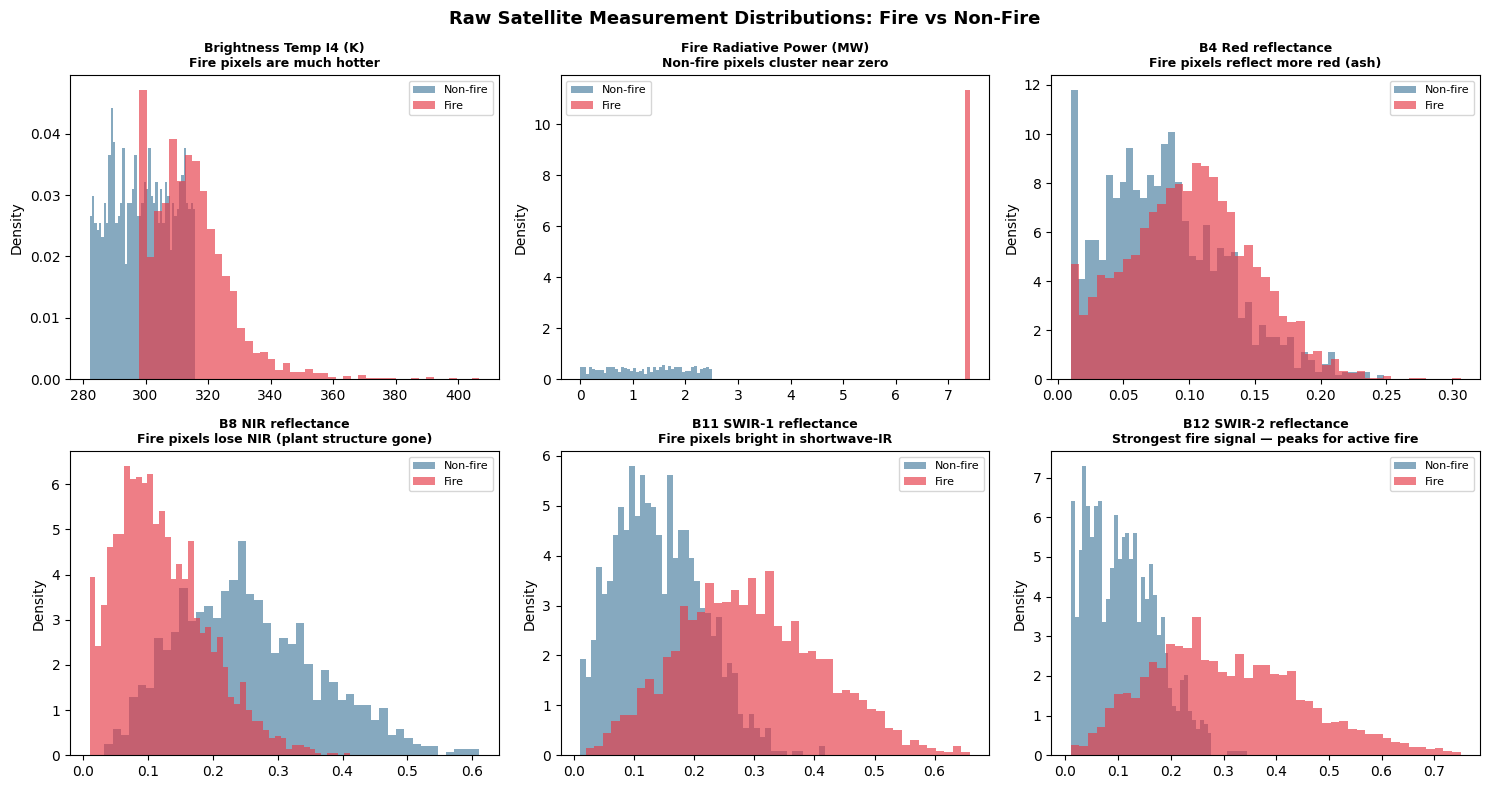

In [60]:
# ── Visualize raw band distributions ─────────────────────────────
#
# For each band, we plot the distribution for fire pixels (red)
# vs non-fire pixels (blue). The more separated the two curves,
# the more useful that band is on its own for detecting fire.

fire    = dataset[dataset.fire_label == 1]
nonfire = dataset[dataset.fire_label == 0]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Raw Satellite Measurement Distributions: Fire vs Non-Fire',
             fontsize=13, fontweight='bold')

plot_cols = [
    ('bright_ti4', 'Brightness Temp I4 (K)\nFire pixels are much hotter'),
    ('frp',        'Fire Radiative Power (MW)\nNon-fire pixels cluster near zero'),
    ('B4_Red',     'B4 Red reflectance\nFire pixels reflect more red (ash)'),
    ('B8_NIR',     'B8 NIR reflectance\nFire pixels lose NIR (plant structure gone)'),
    ('B11_SWIR1',  'B11 SWIR-1 reflectance\nFire pixels bright in shortwave-IR'),
    ('B12_SWIR2',  'B12 SWIR-2 reflectance\nStrongest fire signal — peaks for active fire'),
]

for ax, (col, title) in zip(axes.flat, plot_cols):
    clip_val = nonfire[col].quantile(0.99) * 3
    ax.hist(nonfire[col].clip(upper=clip_val), bins=45, alpha=0.65,
            color='#457B9D', label='Non-fire', density=True)
    ax.hist(fire[col].clip(upper=clip_val),    bins=45, alpha=0.65,
            color='#E63946', label='Fire',     density=True)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 3 — Spectral Indices

### Why not just use the raw bands directly?

A single band value is noisy — the exact reflectance in B8 depends on sun angle, atmospheric haze, viewing geometry, and soil type underneath the vegetation. If you train a model on raw bands, it may learn those confounders instead of the fire signal.

**Spectral indices** are ratios or differences between bands that cancel out shared noise and isolate the specific physical signal we care about. Think of it like using a ratio: even if overall brightness varies, the *ratio* of NIR to Red is a much more stable indicator of vegetation health.

---

### NDVI — Normalized Difference Vegetation Index
$$\text{NDVI} = \frac{B8_{NIR} - B4_{Red}}{B8_{NIR} + B4_{Red}}$$

**Range:** −1.0 to +1.0

Dense healthy vegetation → NDVI near **+1.0** (high NIR, low Red).  
Bare soil → near **0**.  
Burned area → can go **negative** (NIR collapses, Red rises from ash).

The normalization (dividing by the sum) means the result is unaffected by overall brightness — two pixels with the same vegetation density but different illumination will have the same NDVI.

---

### NBR — Normalized Burn Ratio
$$\text{NBR} = \frac{B8_{NIR} - B12_{SWIR2}}{B8_{NIR} + B12_{SWIR2}}$$

**Range:** −1.0 to +1.0

Healthy vegetation → NBR near **+1.0** (high NIR, low SWIR2).  
Fresh burn scar → **strongly negative** (NIR is gone, SWIR2 spikes).

This is the standard metric in fire ecology research. Scientists compute **dNBR = pre-fire NBR − post-fire NBR** to measure how severely an area burned. A dNBR above ~0.66 is classified as "high severity" burn.

---

### BAI — Burned Area Index
$$\text{BAI} = \frac{1}{(0.1 - B4_{Red})^2 + (0.06 - B8_{NIR})^2}$$

**Range:** 1 to 1000+ (we log-transform it)

The formula is specifically engineered so the denominator approaches **zero** when Red ≈ 0.1 and NIR ≈ 0.06 — which are the exact reflectance values typical for **actively burning** pixels. This makes BAI explode to very large values for fire pixels.

More sensitive than NBR for actively burning pixels (as opposed to old burn scars). We apply `log(1 + BAI)` because the raw values span several orders of magnitude.

---

### MIRBI — Mid-Infrared Burn Index
$$\text{MIRBI} = 10 \times B12_{SWIR2} - 9.8 \times B11_{SWIR1} + 2$$

**Range:** approximately −2 to +10

Near **zero** for unburned vegetation. **Rises** significantly for burned or burning surfaces.

The coefficients (10 and 9.8) were derived empirically to cancel the noise that SWIR1 and SWIR2 share (moisture effects, atmospheric scattering), leaving only the unique fire signal that lives in the 2190 nm band.

In [61]:
# The indices are already in the CSV  let's verify them

idx_cols = ['NDVI', 'NBR', 'BAI_log', 'MIRBI', 'SWIR_ratio']

comparison_idx = dataset.groupby('fire_label')[idx_cols].mean().round(3)
comparison_idx.index = ['Non-fire', 'Fire']
print('Mean index values by class:')
print(comparison_idx.to_string())
print()
print('Key patterns:')
print('  NDVI     fire pixels are LOWER (vegetation destroyed)')
print('  NBR      fire pixels are LOWER / negative (burn scar signature)')
print('  BAI_log  fire pixels are HIGHER (spikes for active fire)')
print('  MIRBI    fire pixels are HIGHER (SWIR2 dominates in fire)')

Mean index values by class:
           NDVI    NBR  BAI_log  MIRBI  SWIR_ratio
Non-fire  0.475  0.373    3.567  1.697       0.906
Fire      0.057 -0.384    5.314  2.188       1.188

Key patterns:
  NDVI     fire pixels are LOWER (vegetation destroyed)
  NBR      fire pixels are LOWER / negative (burn scar signature)
  BAI_log  fire pixels are HIGHER (spikes for active fire)
  MIRBI    fire pixels are HIGHER (SWIR2 dominates in fire)


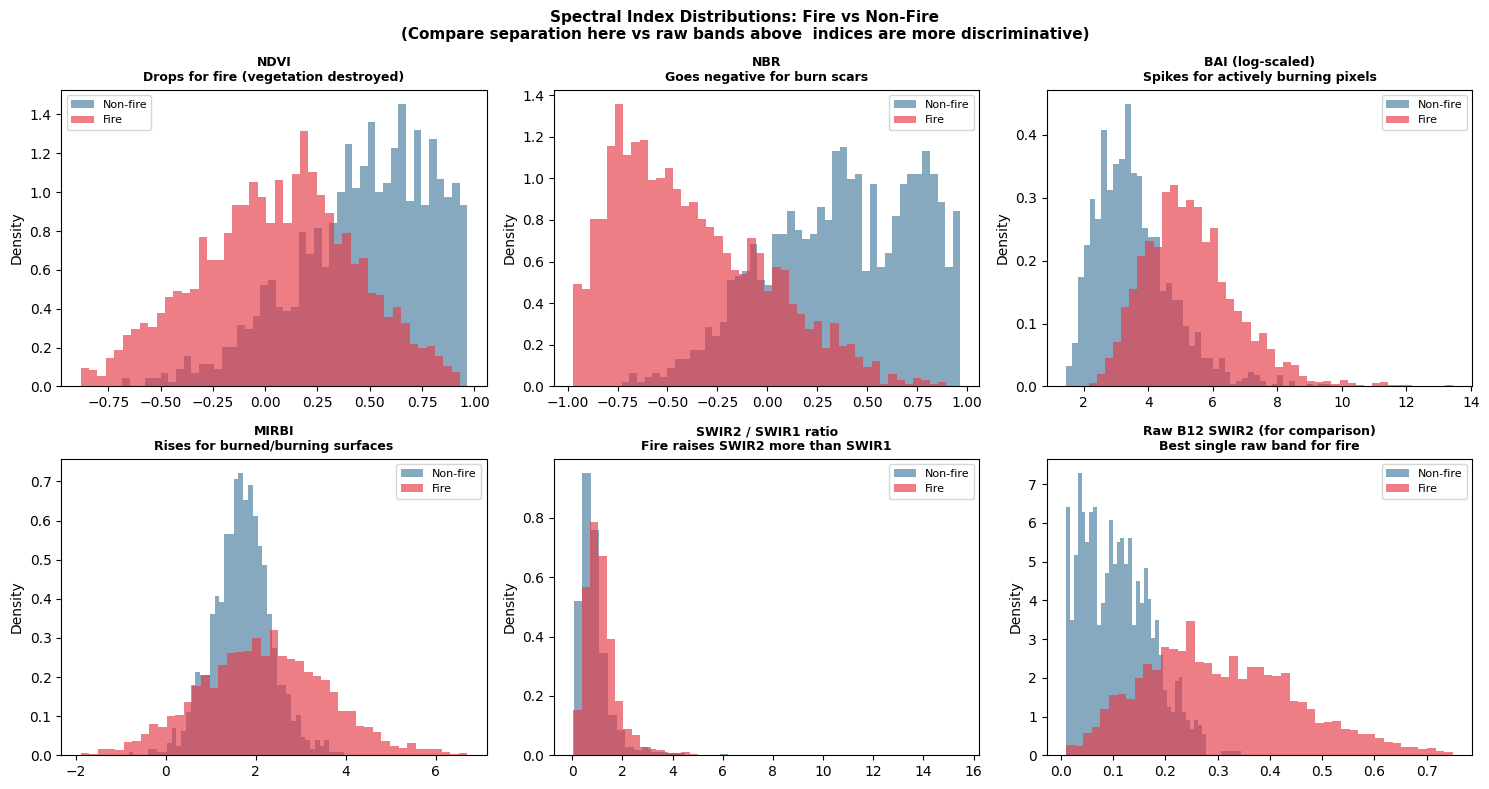

In [62]:
# Visualize index distributions
#
# Compare these plots to the raw band plots above.
# Notice how much MORE separated fire and non-fire are after
# computing indices  this is exactly why we engineer features.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Spectral Index Distributions: Fire vs Non-Fire\n'
             '(Compare separation here vs raw bands above  indices are more discriminative)',
             fontsize=11, fontweight='bold')

index_cols = [
    ('NDVI',       'NDVI\nDrops for fire (vegetation destroyed)'),
    ('NBR',        'NBR\nGoes negative for burn scars'),
    ('BAI_log',    'BAI (log-scaled)\nSpikes for actively burning pixels'),
    ('MIRBI',      'MIRBI\nRises for burned/burning surfaces'),
    ('SWIR_ratio', 'SWIR2 / SWIR1 ratio\nFire raises SWIR2 more than SWIR1'),
    ('B12_SWIR2',  'Raw B12 SWIR2 (for comparison)\nBest single raw band for fire'),
]

fire    = dataset[dataset.fire_label == 1]
nonfire = dataset[dataset.fire_label == 0]

for ax, (col, title) in zip(axes.flat, index_cols):
    ax.hist(nonfire[col], bins=45, alpha=0.65, color='#457B9D', label='Non-fire', density=True)
    ax.hist(fire[col],    bins=45, alpha=0.65, color='#E63946', label='Fire',     density=True)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

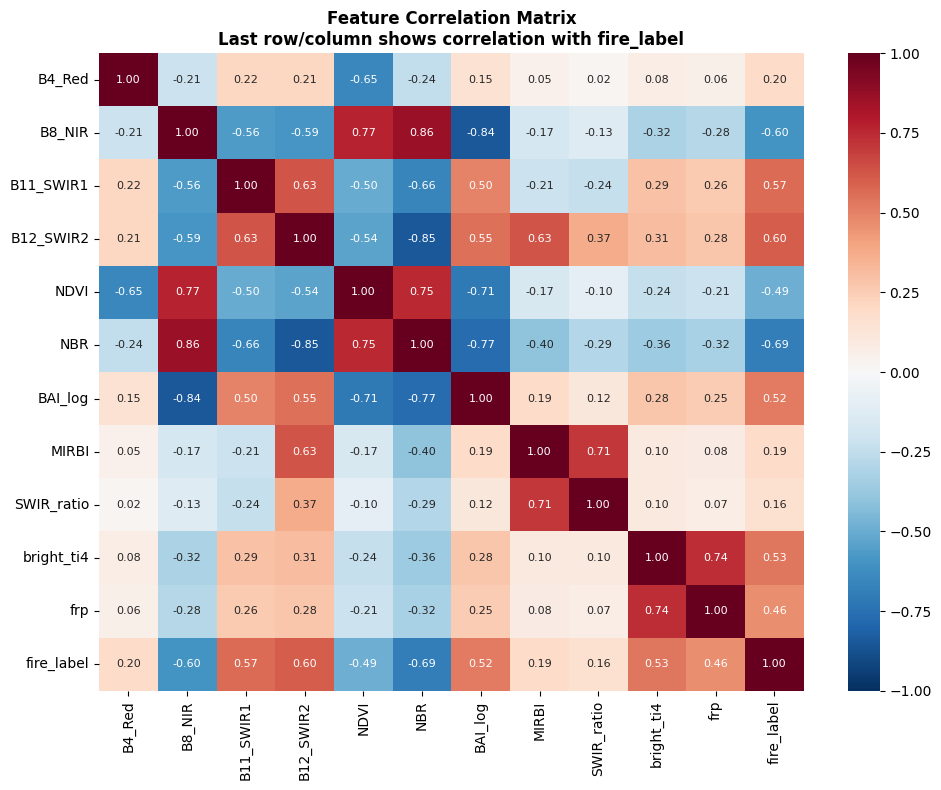

Top correlations with fire_label:
  NBR             -0.694
  B12_SWIR2       +0.602
  B8_NIR          -0.596
  B11_SWIR1       +0.566
  bright_ti4      +0.534
  BAI_log         +0.519
  NDVI            -0.488
  frp             +0.464
  B4_Red          +0.195
  MIRBI           +0.189
  SWIR_ratio      +0.161


In [63]:
# Correlation heatmap
#
# Which features are most correlated with fire_label?
# And which features are correlated with each other
# (redundant information)?

feature_cols = ['B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2',
                'NDVI', 'NBR', 'BAI_log', 'MIRBI', 'SWIR_ratio',
                'bright_ti4', 'frp', 'fire_label']

corr = dataset[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix\n'
             'Last row/column shows correlation with fire_label',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('Top correlations with fire_label:')
fire_corr = corr['fire_label'].drop('fire_label').abs().sort_values(ascending=False)
for feat, val in fire_corr.items():
    direction = '+' if corr.loc[feat, 'fire_label'] > 0 else '-'
    print(f'  {feat:<15} {direction}{val:.3f}')

---
## Step 4 — Train the ML Classifiers

### What problem are we solving?

We have a dataset where each row is one satellite pixel with:
- **Features (X):** spectral bands + fire indices + thermal measurements
- **Label (y):** 1 = fire, 0 = non-fire

This is **binary classification**. The model needs to learn which combination of feature values most reliably indicates fire.

### Why ensemble tree models?

**Random Forest** and **XGBoost** both build many decision trees and combine their predictions. They work well here because:
- They handle non-linear relationships (fire doesn't have a simple linear threshold)
- They don't require feature scaling
- They give us feature importances — telling us which measurements the model actually relies on
- They're robust to the noise in satellite data

**Random Forest:** builds 200 trees independently, each on a random data/feature subset. Final answer = majority vote.

**XGBoost:** builds 300 trees sequentially. Each new tree specifically targets the mistakes the previous trees made. Usually more accurate but slower to train.

In [64]:
# ── Define features and split ─────────────────────────────────────
#
# We use only the Sentinel-2 spectral features here — not the FIRMS
# thermal columns (bright_ti4, frp). Why? Because in a real production
# system you'd often want to detect fire from optical imagery alone,
# without requiring a simultaneous thermal overpass. It's also a harder
# and more interesting ML problem — the spectral signal alone should be
# enough if our indices are well-engineered.
#
# (Feel free to add 'bright_ti4' and 'frp' back and see what happens
# to performance — it's a good experiment.)

FEATURES = [
    'B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2',    # Raw Sentinel-2 bands
    'NDVI', 'NBR', 'BAI_log', 'MIRBI', 'SWIR_ratio',  # Spectral fire indices
]

X = dataset[FEATURES].copy()
y = dataset['fire_label']

X['BAI_log'] = X['BAI_log'].clip(upper=20)

# 75% training, 25% test
# stratify=y ensures the fire/non-fire ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features:         {len(FEATURES)}')
print(f'Class balance (train): {y_train.mean():.1%} fire, {1-y_train.mean():.1%} non-fire')
print()
print('💡 Experiment: try adding "bright_ti4" and "frp" to FEATURES above.')
print('   Both are thermal measurements from the satellite — how much does AUC improve?')


Training samples: 2,670
Test samples:     890
Features:         9
Class balance (train): 66.3% fire, 33.7% non-fire

💡 Experiment: try adding "bright_ti4" and "frp" to FEATURES above.
   Both are thermal measurements from the satellite — how much does AUC improve?


In [65]:
# Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,    # 200 independent decision trees
    max_depth=12,        # Limit depth to prevent overfitting
    min_samples_leaf=5,  # Each leaf must have at least 5 samples
    n_jobs=-1,           # Use all CPU cores
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)

print('=== Random Forest ===')
print(f'AUC-ROC: {rf_auc:.4f}')
print(classification_report(y_test, rf_pred, target_names=['Non-fire', 'Fire']))

=== Random Forest ===
AUC-ROC: 0.9459
              precision    recall  f1-score   support

    Non-fire       0.81      0.82      0.82       300
        Fire       0.91      0.90      0.90       590

    accuracy                           0.87       890
   macro avg       0.86      0.86      0.86       890
weighted avg       0.87      0.87      0.87       890



In [66]:
# Train XGBoost

xgb_model = xgb.XGBClassifier(
    n_estimators=300,      # 300 trees built sequentially
    max_depth=6,           # Shallower than RF  XGB uses more trees
    learning_rate=0.05,    # How aggressively each tree corrects errors
    subsample=0.8,         # Use 80% of samples per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print('=== XGBoost ===')
print(f'AUC-ROC: {xgb_auc:.4f}')
print(classification_report(y_test, xgb_pred, target_names=['Non-fire', 'Fire']))

=== XGBoost ===
AUC-ROC: 0.9389
              precision    recall  f1-score   support

    Non-fire       0.78      0.84      0.81       300
        Fire       0.91      0.88      0.90       590

    accuracy                           0.87       890
   macro avg       0.85      0.86      0.85       890
weighted avg       0.87      0.87      0.87       890



---
## Step 5 — Evaluate & Visualize

### Why not just use accuracy?

In any real satellite pass, only 5–15% of pixels are on fire. A model that predicts "no fire" for *everything* would be 85–95% accurate — but completely useless. We need metrics that penalize missed fires.

| Metric | What it measures | Why it matters for fire |
|--------|-----------------|------------------------|
| **AUC-ROC** | How well the model separates fire from non-fire at *every* possible threshold. 1.0 = perfect, 0.5 = random. Unaffected by class imbalance. | Best overall performance metric |
| **Precision** | Of all pixels flagged as fire, what fraction actually are? Low precision = too many false alarms. | Costly for emergency responders |
| **Recall** | Of all actual fire pixels, what fraction did the model catch? Low recall = missed fires. | **Most dangerous failure mode** |
| **F1 Score** | Harmonic mean of precision and recall. Single number that balances both. | Useful for model comparison |

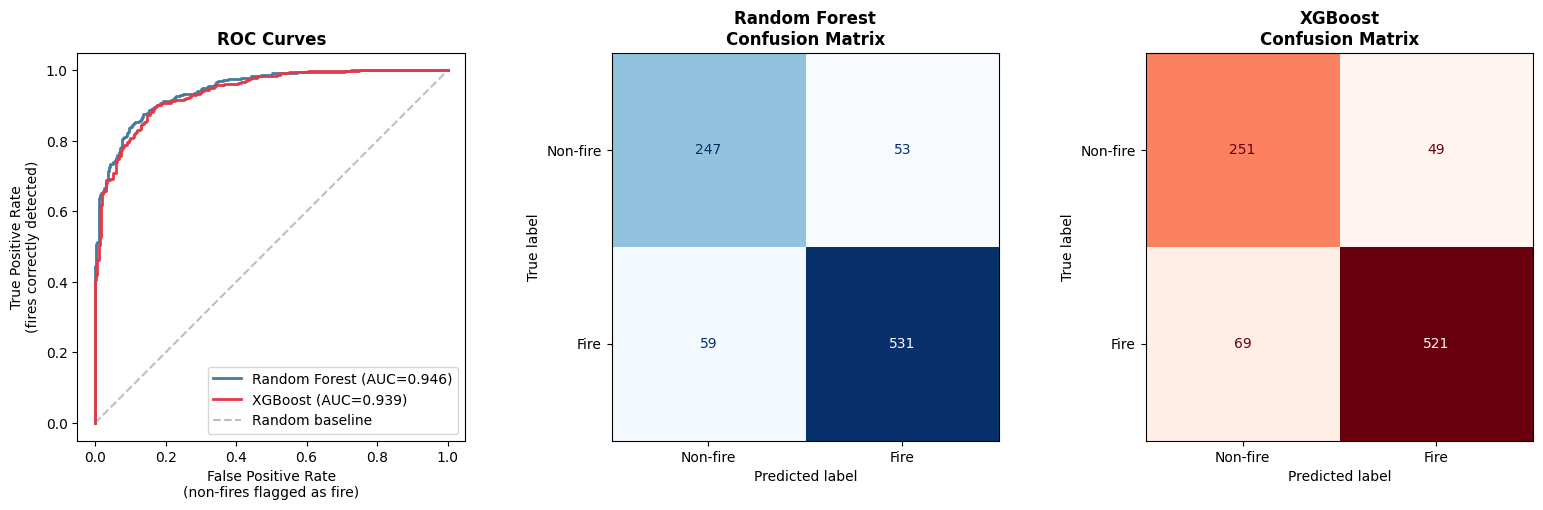

In [67]:
# ROC curves + confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC Curves
# The curve plots True Positive Rate (fires caught) vs False Positive Rate
# (non-fires wrongly flagged) at every possible decision threshold.
# A perfect model hugs the top-left corner. The diagonal = random guessing.
ax = axes[0]
for name, prob, color in [
    ('Random Forest', rf_prob, '#457B9D'),
    ('XGBoost',       xgb_prob, '#E63946')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test,prob):.3f})',
            color=color, lw=2)
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random baseline')
ax.set_xlabel('False Positive Rate\n(non-fires flagged as fire)')
ax.set_ylabel('True Positive Rate\n(fires correctly detected)')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend()
ax.set_aspect('equal')

# Confusion matrices
# Top-left: correctly said non-fire (true negative)
# Bottom-right: correctly said fire (true positive)
# Top-right: said fire but wasn't (false positive = false alarm)
# Bottom-left: said non-fire but was fire (false negative = MISSED FIRE)
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, display_labels=['Non-fire','Fire'],
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Random Forest\nConfusion Matrix', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred, display_labels=['Non-fire','Fire'],
    ax=axes[2], colorbar=False, cmap='Reds'
)
axes[2].set_title('XGBoost\nConfusion Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

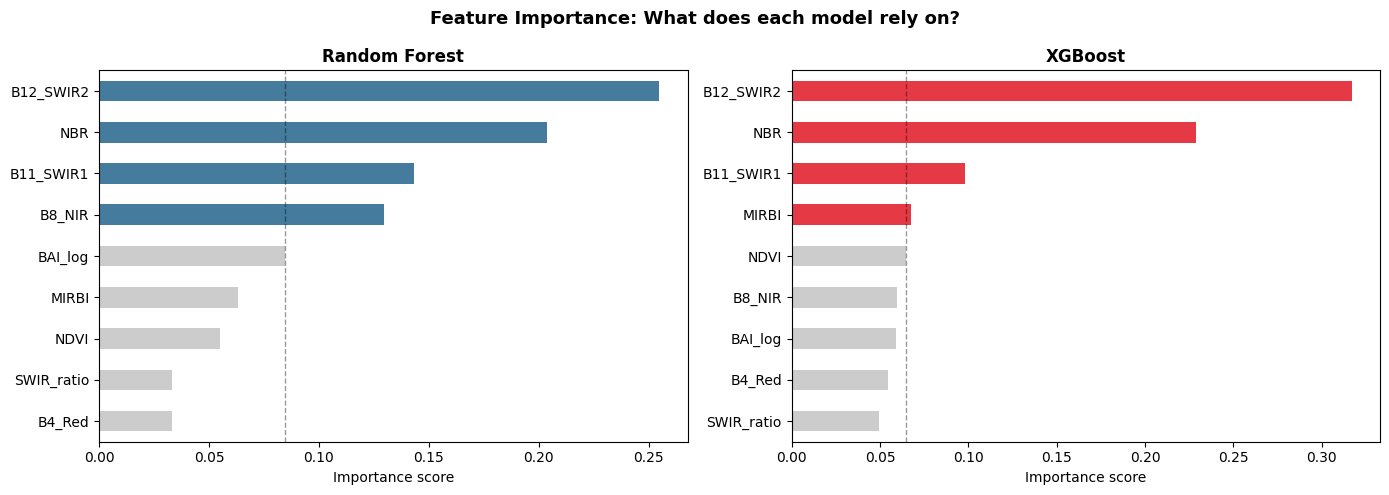

Top 3 features  Random Forest: ['B12_SWIR2', 'NBR', 'B11_SWIR1']
Top 3 features  XGBoost:       ['B12_SWIR2', 'NBR', 'B11_SWIR1']


In [68]:
# Feature importance
#
# Which features did each model rely on most?
# This is interpretable science  if SWIR2 and FRP dominate,
# the thermal/infrared fire signal is key. If NDVI/NBR dominate,
# vegetation damage is the stronger predictor.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importance: What does each model rely on?',
             fontweight='bold', fontsize=13)

for ax, model, name, color in [
    (axes[0], rf_model,  'Random Forest', '#457B9D'),
    (axes[1], xgb_model, 'XGBoost',       '#E63946')
]:
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    bar_colors = [color if v > imp.median() else '#CCCCCC' for v in imp]
    imp.plot(kind='barh', ax=ax, color=bar_colors)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance score')
    ax.axvline(x=imp.median(), color='black', linestyle='--', alpha=0.4, lw=1)

plt.tight_layout()
plt.show()

top3_rf  = pd.Series(rf_model.feature_importances_,  index=FEATURES).nlargest(3)
top3_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).nlargest(3)
print('Top 3 features  Random Forest:', list(top3_rf.index))
print('Top 3 features  XGBoost:      ', list(top3_xgb.index))

In [69]:
X_full = dataset[FEATURES].copy()
X_full['BAI_log'] = X_full['BAI_log'].clip(upper=20)

dataset = dataset.copy()
dataset['rf_prob']  = rf_model.predict_proba(X_full)[:, 1]
dataset['xgb_prob'] = xgb_model.predict_proba(X_full)[:, 1]

# Center map on the mean of all fire locations
fire_rows = dataset[dataset.fire_label == 1]
center_lat = fire_rows.latitude.mean()
center_lon = fire_rows.longitude.mean()

---
## Challenge: Can you beat the baseline?

Try changing the XGBoost hyperparameters below and see if your AUC goes up.

**Things to try:**
- Increase `n_estimators` (more trees = more learning, but slower)
- Lower `learning_rate` and increase `n_estimators` together
- Change `max_depth` — deeper trees capture more complexity but overfit more
- Try removing some features from `FEATURES` — which ones hurt performance?

In [70]:
my_model = xgb.XGBClassifier(
    n_estimators=300,     # Try: 100  1000
    max_depth=6,          # Try: 3  10
    learning_rate=0.05,   # Try: 0.01  0.3
    subsample=0.8,        # Try: 0.5  1.0
    colsample_bytree=0.8, # Try: 0.5  1.0
    eval_metric='logloss',
    random_state=42,
    verbosity=0
)
my_model.fit(X_train, y_train)
my_auc = roc_auc_score(y_test, my_model.predict_proba(X_test)[:, 1])

print(f'Baseline XGBoost AUC: {xgb_auc:.4f}')
print(f'Your model AUC:       {my_auc:.4f}')
delta = my_auc - xgb_auc
print(f'Difference: {delta:+.4f}  {"Improvement!" if delta > 0.001 else "Try adjusting the parameters"}')
print()
print(' Also try adding thermal features:')
print('   X_train_thermal = pd.concat([X_train, dataset.loc[X_train.index, ["bright_ti4","frp"]]], axis=1)')

Baseline XGBoost AUC: 0.9389
Your model AUC:       0.9389
Difference: +0.0000  Try adjusting the parameters

 Also try adding thermal features:
   X_train_thermal = pd.concat([X_train, dataset.loc[X_train.index, ["bright_ti4","frp"]]], axis=1)
